# Branch Structure

## Static Branch

In [44]:
from typing import TypedDict, Literal, Sequence

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.prompt_values import PromptValue
from langchain_core.prompts import HumanMessagePromptTemplate, ChatPromptTemplate
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import Send, Command
from loguru import logger
from rich import print as rprint

In [8]:
load_dotenv(override=True)
model = init_chat_model(model="deepseek:deepseek-v4-flash")

### Parallel Node

`Node A` and `Node B` are running concurrently

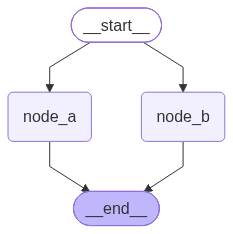

{
    'topic': '喵',
    'poem': '《喵》\n花间忽闻一声喵，  \n踏雪寻来影自娇。  \n原是狸奴闲弄舌，  \n春风过处柳丝摇。',
    'joke': '小猫写作文，题目是《我的理想》。它只写了三个字：“喵喵喵。”\n\n猫老师看后，批语写道：“喵不可言。”'
}

In [12]:
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str


def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke(
        [
            HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")
        ]
    ).content
    return {
        "poem": poem
    }


def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke(
        [
            HumanMessage(f"写一个关于 {state['topic']} 的笑话")
        ]
    ).content
    return {
        "joke": joke
    }


builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a).add_node(node_b)
# builder.add_edge(START, "node_a").add_edge(START, "node_b")
builder.set_entry_point("node_a").set_entry_point("node_b")
graph = builder.compile()
display(graph)

response = graph.invoke({"topic": "喵"})
rprint(response)

### Conditional Edge

Determine the next node to invoke directly from the return value of the routing function.

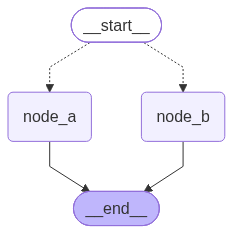

{
    'topic': '喵',
    'poem': '《咏喵》\n花间小爪扑流萤，忽向窗台侧耳听。\n一点春心藏不住，喵声软软唤人应。',
    'content_type': 'poem'
}

In [18]:
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str


def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke(
        [
            HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")
        ]
    ).content
    return {
        "poem": poem
    }


def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke(
        [
            HumanMessage(f"写一个关于 {state['topic']} 的笑话")
        ]
    ).content
    return {
        "joke": joke
    }


def route(state: OverAllState) -> Literal["node_a", "node_b"]:
    if "poem" in state["content_type"]:
        return "node_a"
    else:
        return "node_b"


builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a).add_node(node_b)
builder.add_conditional_edges(START, route)

graph = builder.compile()
display(graph)

response = graph.invoke({"topic": "喵", "content_type": "poem"})
rprint(response)

In [19]:
response = graph.invoke({"topic": "喵", "content_type": "anything else"})
rprint(response)

{
    'topic': '喵',
    'joke': '主人问猫：“你会说成语吗？”  \n猫：“喵不可言。”  \n主人：“那不是‘妙不可言’吗？”  
\n猫：“对，但我是猫，所以是‘喵不可言’。”',
    'content_type': 'anything else'
}

Define a path map that maps each possible return value of the routing function to the corresponding node name.

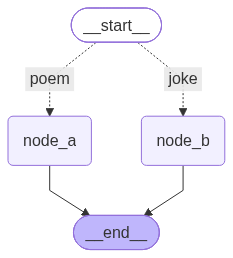

{
    'topic': '喵',
    'poem': '《喵》\n\n花影阶前小步娇，  \n蝶飞忽驻眼凝瞧。  \n弓身欲扑还轻唤，  \n却作春风一响喵。',
    'content_type': 'poem'
}

In [20]:
def route(state: OverAllState) -> Literal["poem", "joke"]:
    if "poem" in state["content_type"]:
        return "poem"
    else:
        return "joke"


builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a).add_node(node_b)
builder.add_conditional_edges(
    START,
    route,
    {
        "poem": "node_a",
        "joke": "node_b",
    }
)

graph = builder.compile()
display(graph)

response = graph.invoke({"topic": "喵", "content_type": "poem"})
rprint(response)

In [21]:
response = graph.invoke({"topic": "喵", "content_type": "anything else"})
rprint(response)

{
    'topic': '喵',
    'joke': '小猫打碎了花瓶。  \n猫妈妈问：“这是不是你干的？”  \n小猫弱弱地叫了一声：“喵……”  
\n\n猫妈妈眼睛一瞪：“喵？你还觉得挺妙？”  \n小猫吓得赶紧喊：“不喵！不喵！”  
\n\n猫妈妈点点头：“这还差不多，知道不妙就好。”',
    'content_type': 'anything else'
}

#### Route the multiple nodes in the same superstep

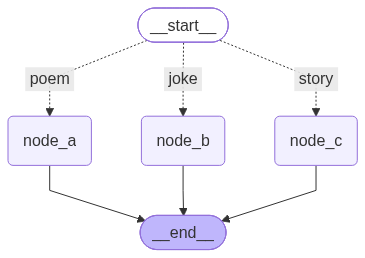

{
    'topic': '喵',
    'poem': '《咏喵》\n狸奴小爪弄春风，忽见游蜂舞碧空。\n欲唤芳名先侧耳，一声喵语破朦胧。',
    'story': 
'喵蹲在窗台，看雨滴追着雨滴。它忽然回头，冲我轻轻叫了一声。我笑了，把伞递过去。它却跳进我怀里，说：“你才是我的屋檐
。”',
    'content_type': 'poem'
}

In [49]:
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    story: str
    content_type: str


def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke(
        [
            HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")
        ]
    ).content
    return {
        "poem": poem
    }


def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke(
        [
            HumanMessage(f"写一个关于 {state['topic']} 的笑话")
        ]
    ).content
    return {
        "joke": joke
    }


def node_c(state: OverAllState) -> OverAllState:
    story = model.invoke(
        [
            HumanMessage(f"写一个关于 {state['topic']} 的 50 字小故事")
        ]
    ).content
    return {
        "story": story
    }


def route(state: OverAllState) -> Sequence[Literal["poem", "joke", "story"]]:
    if "poem" in state["content_type"]:
        return ["poem", "story"]
    else:
        return ["joke", "story"]


builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a).add_node(node_b).add_node(node_c)
builder.add_conditional_edges(
    START,
    route,
    {
        "poem": "node_a",
        "joke": "node_b",
        "story": "node_c",
    }
)

graph = builder.compile()
display(graph)

response = graph.invoke({"topic": "喵", "content_type": "poem"})
rprint(response)

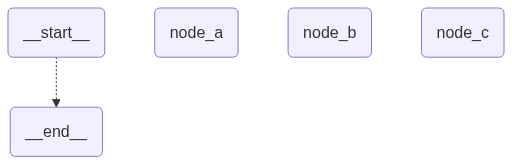

{
    'topic': '喵',
    'joke': 
'猫妈妈教小猫说“喵”：\n\n“孩子，咱们猫的字很少，就一个‘喵’，其实是‘妙’。”\n\n小猫：“那我懂了！妙不可言＝喵不可言，
莫名其妙＝莫名其喵，妙手回春＝喵手回春！”\n\n猫妈妈：“那你翻译一下‘喵喵喵’。”\n\n小猫：“妙妙妙！”\n\n猫妈妈：“不对
，是‘我要吃鱼，现在立刻马上！’”',
    'story': 
'喵是一只总想抓住影子的小猫。每天黄昏，它扑向地上的影子，影子碎成了金粉。喵轻轻地叫了，突然，金粉飞起，化作满天星光
。',
    'content_type': 'anything else'
}

In [50]:
def route(state: OverAllState) -> Sequence[Literal["node_a", "node_b", "node_c"]]:
    if "poem" in state["content_type"]:
        return ["node_a", "node_c"]
    else:
        return ["node_b", "node_c"]


builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a).add_node(node_b).add_node(node_c)
builder.add_conditional_edges(
    START,
    route,
)

graph = builder.compile()
display(graph)

response = graph.invoke({"topic": "喵", "content_type": "anything else"})
rprint(response)

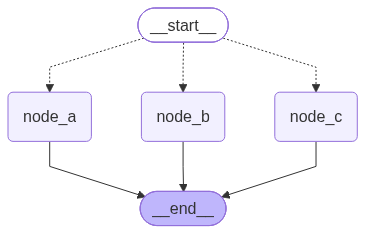

In [27]:
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a).add_node(node_b).add_node(node_c)
builder.add_conditional_edges(
    START,
    route,
    ["node_a", "node_b", "node_c"],
)

graph = builder.compile()
display(graph)

### Defer Node Execution

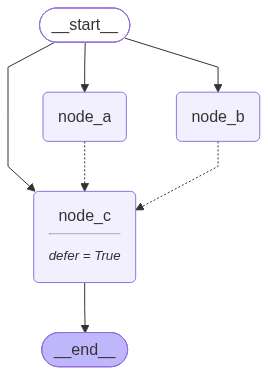

In [33]:
# Define a defer node in graph

builder = StateGraph(state_schema=OverAllState)


def node_c(state: OverAllState) -> OverAllState | None:
    logger.info(
        f"任务节点全部执行完毕，诗 {'已生成' if state['poem'] else '未生成'}，笑话 {'已生成' if state['joke'] else '未生成'}")


builder.add_node(node_a).add_node(node_b).add_node(node_c, defer=True)
builder.set_entry_point("node_a").set_entry_point("node_b").set_entry_point("node_c")
# Optional, nothing happened for the graph
builder.add_edge("node_a", END).add_edge("node_b", END).add_edge("node_c", END)

graph = builder.compile()
display(graph)

In [35]:
# Invoke the graph

response = graph.invoke({"topic": "喵"})
rprint(response)

2026-08-12 21:56:12.347 | INFO     | __main__:node_c:4 - 任务节点全部执行完毕，诗 已生成，笑话 已生成


{
    'topic': '喵',
    'poem': '《喵》\n\n喵喵小院日光华，\n懒卧花阴梦落花。\n乍见檐间飞影过，\n腾身纵跃上云霞。',
    'joke': 
'主人问猫：“你为什么整天喵喵喵？”\n\n猫说：“我在夸自己妙呀！”\n\n主人：“那你倒说说，你哪里妙？”\n\n猫：“妙不可言——
所以只能喵。”'
}

## Dymnamic Branch

### Parallel Nodes

`Send` and `add_conditional_edge()` can be used together to fan out tasks.

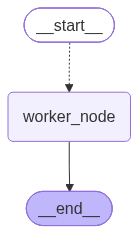

{
    'poem': 
'**《猫》**\n\n它不是月下的影子，\n是影子学会了轻盈；\n它不是夜的私语，\n是私语有了形状。\n\n圆眼盛着古老的静，\n胡
须丈量黎明的宽度；\n它走过的地方，\n时间软成一截毛线。\n\n爪尖收拢整座花园，\n呵欠里藏着虎的韵律；\n阳光在皮毛上打
盹，\n而它的尾巴，正拨动\n人间的某个偏旁。\n\n若它忽然停下凝视你，\n别问——\n那是在校对\n你灵魂里褪色的笔迹。',
    'joke': '一只猫去饭店吃饭，服务员问：“您要点什么？”  \n猫说：“给我来条鱼。”  \n服务员又问：“您要几分熟？”  
\n猫不耐烦：“喵的，我要生鱼片！”',
    'story': '# 
小橘猫的月亮奇遇\n\n从前，有一只名叫“小橘子”的橘猫，它住在一个温暖的小镇里。小橘子有一身阳光般的橘色毛发，还有一双
好奇的大眼睛，总爱望着夜空发呆。\n\n有一天晚上，小橘子像往常一样趴在窗台上看月亮。突然，它发现月亮上有个闪闪发光的
小东西在朝自己挥手！\n\n“喵？”小橘子揉了揉眼睛，不敢相信。\n\n那是月亮的守护精灵——一只银色的小猫咪，名字叫“月月”。
月月对小橘子说：“我听说你是最勇敢的猫，能帮我把掉落在人间的星星碎片找回来吗？没有它们，月亮的光就会变暗。”\n\n小橘
子毫不犹豫地答应了。它跳下窗台，穿梭在夜色中——\n\n它先来到花园里，在茉莉花丛下找到了一颗像露珠一样闪亮的碎片；接着
，它爬上老槐树，在鸟巢旁边发现了第二颗；最后，它跳进池塘，用尾巴小心翼翼地捞起了第三颗。\n\n月月把碎片拼回月亮上，
霎时间，银色的光辉洒满了小镇，比任何时候都要明亮。\n\n“谢谢你，小橘子！”月月摇晃着尾巴，“从今以后，你每晚抬头，都会
看到月亮上有一个属于你的光点。”\n\n从那以后，小橘子成了小镇上最特别的小猫。每个夜晚，它都会坐在屋顶上，对着月亮“喵
喵”两声，而月亮上那颗最亮的光点，也会一闪一闪地回应它。\n\n——晚安，愿所有小猫都能拥有月亮般温柔的美梦。🌙'
}

In [42]:
# Fan-out case

CONTENT_TYPES = ["poem", "joke", "story"]


class OverallState(TypedDict):
    topic: str
    poem: str
    joke: str
    story: str


class InputState(TypedDict):
    topic: str


class OutputState(TypedDict):
    poem: str
    joke: str
    story: str


class WorkerState(TypedDict):
    content_type: Literal["poem", "joke", "story"]
    prompt: PromptValue


def worker_node(state: WorkerState) -> OutputState:
    content_type = state["content_type"]
    prompt = state["prompt"]
    content = model.invoke(input=prompt).content
    return {
        content_type: content
    }


def router(state: InputState) -> Sequence[Send]:
    prompt_template = ChatPromptTemplate.from_messages(
        [HumanMessagePromptTemplate.from_template("Generate {content_type} for {topic}, respond in Chinese")]
    )
    return [
        Send(
            node="worker_node",
            arg={
                "content_type": content_type,
                "prompt": prompt_template.invoke({"content_type": content_type, "topic": state["topic"]})
            }
        ) for content_type in CONTENT_TYPES
    ]


workflow = StateGraph(state_schema=OverallState, input_schema=InputState, output_schema=OutputState)
workflow.add_node(worker_node)
workflow.add_conditional_edges(START, router, ["worker_node"]).add_edge("worker_node", END)
graph = workflow.compile()
display(graph)

response = graph.invoke({
    "topic": "cat"
})
rprint(response)

### Conditional Branch

#### Command

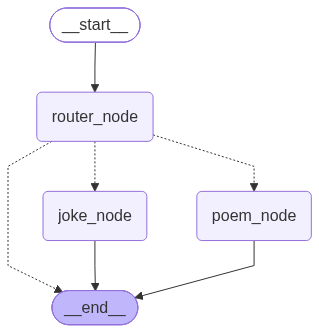

{
    'topic': 'cat',
    'poem': '《猫》\n\n你从月光里走来，  \n爪尖上沾着夜的露水。  \n瞳孔是两粒琥珀，  \n映过千年未解的谜。  
\n\n你不属于任何名字，  \n却回应每一声呼唤，  \n不过是慵懒地甩甩尾巴，  \n把温柔藏进咕噜声里。  
\n\n纸箱比王座更合你意，  \n一束阳光便够你躺卧。  \n你伏在窗台上凝视远方，  \n仿佛世界本就该这样静谧。',
    'chinese_content_type': '诗',
    'content_type': 'poem'
}

{
    'topic': 'cat',
    'joke': '问：一只会弹钢琴的猫叫什么名字？  \n答：喵扎特（Mozart）！',
    'chinese_content_type': '玩笑',
    'content_type': 'joke'
}

{'topic': 'cat', 'content_type': 'any'}

In [47]:
# Command Example

class OverallState(TypedDict):
    topic: str
    poem: str
    joke: str
    chinese_content_type: str
    content_type: str


def router_node(state: OverallState) -> Command[Literal["poem_node", "joke_node", "__end__"]]:
    if state["content_type"] == "poem":
        return Command(
            update={
                "chinese_content_type": "诗"
            },
            goto="poem_node",
        )
    elif state["content_type"] == "joke":
        return Command(
            update={
                "chinese_content_type": "玩笑"
            },
            goto="joke_node",
        )
    else:
        return Command(goto=END)


def poem_node(state: OverallState) -> OverallState:
    chinese_content_type = state["chinese_content_type"]
    topic = state["topic"]
    response = model.invoke(input=f"写一个关于{topic}的{chinese_content_type}")
    return {
        "poem": response.content
    }


def joke_node(state: OverallState) -> OverallState:
    chinese_content_type = state["chinese_content_type"]
    topic = state["topic"]
    response = model.invoke(input=f"写一个关于{topic}的{chinese_content_type}")
    return {
        "joke": response.content
    }


workflow = StateGraph(OverallState)
workflow.add_node(poem_node).add_node(joke_node).add_node(router_node)
workflow.set_entry_point("router_node")
workflow.add_edge("poem_node", END).add_edge("router_node", END)

graph = workflow.compile()

display(graph)

response = graph.invoke({
    "topic": "cat",
    "content_type": "poem"
})
rprint(response)

response = graph.invoke({
    "topic": "cat",
    "content_type": "joke"
})
rprint(response)

response = graph.invoke({
    "topic": "cat",
    "content_type": "any"
})
rprint(response)
